In [1]:
from pathlib import Path
import math
import time

import pandas as pd
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models

In [2]:
BASE_DIR = Path("clock_project")
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

LABELS_PATH = DATA_DIR / "labels.csv"

DIGITAL_MODEL_PATH = MODELS_DIR / "digital_time_reader.pth"
ERASER_MODEL_PATH = MODELS_DIR / "analog_cleaner_eraser_v2.pth"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Labels:", LABELS_PATH.exists())
print("Digital model:", DIGITAL_MODEL_PATH.exists())
print("Eraser model:", ERASER_MODEL_PATH.exists())

Using device: cpu
Labels: True
Digital model: False
Eraser model: False


In [3]:
class DigitalClockClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.bottleneck = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.hour_head = nn.Linear(256, 24)
        self.minute_head = nn.Linear(256, 60)
        self.second_head = nn.Linear(256, 60)

    def forward(self, x):
        features = self.backbone(x)
        features = self.bottleneck(features)

        return (
            self.hour_head(features),
            self.minute_head(features),
            self.second_head(features)
        )

    def predict_time(self, x):
        h, m, s = self.forward(x)
        return h.argmax(1), m.argmax(1), s.argmax(1)

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class ClockEraserV2(nn.Module):
    def __init__(self, base=64):
        super().__init__()

        self.enc1 = ConvBlock(3, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.enc4 = ConvBlock(base * 4, base * 8)

        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = ConvBlock(base * 8, base * 8)

        self.up4 = nn.ConvTranspose2d(base * 8, base * 8, 2, 2)
        self.dec4 = ConvBlock(base * 16, base * 4)

        self.up3 = nn.ConvTranspose2d(base * 4, base * 4, 2, 2)
        self.dec3 = ConvBlock(base * 8, base * 2)

        self.up2 = nn.ConvTranspose2d(base * 2, base * 2, 2, 2)
        self.dec2 = ConvBlock(base * 4, base)

        self.up1 = nn.ConvTranspose2d(base, base, 2, 2)
        self.dec1 = ConvBlock(base * 2, base)

        self.final = nn.Sequential(
            nn.Conv2d(base, 3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        x = self.bottleneck(self.pool(e4))

        x = self.up4(x)
        x = F.interpolate(x, size=e4.shape[2:], mode="bilinear", align_corners=False)
        x = self.dec4(torch.cat([x, e4], dim=1))

        x = self.up3(x)
        x = F.interpolate(x, size=e3.shape[2:], mode="bilinear", align_corners=False)
        x = self.dec3(torch.cat([x, e3], dim=1))

        x = self.up2(x)
        x = F.interpolate(x, size=e2.shape[2:], mode="bilinear", align_corners=False)
        x = self.dec2(torch.cat([x, e2], dim=1))

        x = self.up1(x)
        x = F.interpolate(x, size=e1.shape[2:], mode="bilinear", align_corners=False)
        x = self.dec1(torch.cat([x, e1], dim=1))

        return self.final(x)

In [5]:
digital_model = DigitalClockClassifier().to(DEVICE)
digital_model.load_state_dict(torch.load(DIGITAL_MODEL_PATH, map_location=DEVICE))
digital_model.eval()

eraser_model = ClockEraserV2(base=64).to(DEVICE)
eraser_model.load_state_dict(torch.load(ERASER_MODEL_PATH, map_location=DEVICE))
eraser_model.eval()

print("Models loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'clock_project\\models\\digital_time_reader.pth'

In [6]:
digital_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eraser_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [7]:
def draw_hand(draw, center, angle_rad, length, color, width):
    cx, cy = center
    x = cx + length * math.cos(angle_rad)
    y = cy + length * math.sin(angle_rad)
    draw.line([cx, cy, x, y], fill=color, width=width)


def draw_hands_on_image(clean_image, hour, minute, second):
    img = clean_image.copy()
    draw = ImageDraw.Draw(img)

    w, h = img.size
    cx, cy = w / 2, h / 2
    radius = min(w, h) / 2 - max(5, w // 25)

    hour_angle = math.radians((hour % 12) * 30 + minute * 0.5 - 90)
    minute_angle = math.radians(minute * 6 + second * 0.1 - 90)
    second_angle = math.radians(second * 6 - 90)

    draw_hand(draw, (cx, cy), hour_angle, radius * 0.50, (30, 30, 30), max(3, int(w * 0.04)))
    draw_hand(draw, (cx, cy), minute_angle, radius * 0.75, (30, 30, 30), max(2, int(w * 0.025)))
    draw_hand(draw, (cx, cy), second_angle, radius * 0.85, (200, 40, 40), max(1, int(w * 0.008)))

    cap = max(3, w // 40)
    draw.ellipse([cx - cap, cy - cap, cx + cap, cy + cap], fill=(30, 30, 30))

    return img

In [8]:
def tensor_to_pil(tensor):
    tensor = tensor.detach().cpu().clamp(0, 1)
    array = (tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(array)


def run_pipeline(digital_image, analog_image):
    start = time.time()

    digital_input = digital_transform(digital_image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        h_pred, m_pred, s_pred = digital_model.predict_time(digital_input)

    hour = int(h_pred.item())
    minute = int(m_pred.item())
    second = int(s_pred.item())

    analog_tensor = eraser_transform(analog_image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        clean_tensor = eraser_model(analog_tensor)

    clean_image = tensor_to_pil(clean_tensor.squeeze(0))

    final_output = draw_hands_on_image(
        clean_image,
        hour,
        minute,
        second
    )

    runtime = time.time() - start

    return {
        "hour": hour,
        "minute": minute,
        "second": second,
        "clean_image": clean_image,
        "final_output": final_output,
        "runtime": runtime
    }

In [9]:
df = pd.read_csv(LABELS_PATH)

digital_sample = df.sample(1).iloc[0]
analog_sample = df.sample(1).iloc[0]

while analog_sample["sample_id"] == digital_sample["sample_id"]:
    analog_sample = df.sample(1).iloc[0]

digital_image = Image.open(digital_sample["digital_image_path"]).convert("RGB")
analog_image = Image.open(analog_sample["analog_with_hands_path"]).convert("RGB")

digital_true = (
    int(digital_sample["hour"]),
    int(digital_sample["minute"]),
    int(digital_sample["second"])
)

analog_true = (
    int(analog_sample["hour"]),
    int(analog_sample["minute"]),
    int(analog_sample["second"])
)

result = run_pipeline(digital_image, analog_image)

print(f"Digital true time: {digital_true[0]:02d}:{digital_true[1]:02d}:{digital_true[2]:02d}")
print(f"Analog input time:  {analog_true[0]:02d}:{analog_true[1]:02d}:{analog_true[2]:02d}")
print(f"Predicted time:    {result['hour']:02d}:{result['minute']:02d}:{result['second']:02d}")
print(f"Runtime: {result['runtime']:.4f} seconds")

NameError: name 'eraser_model' is not defined

NameError: name 'result' is not defined

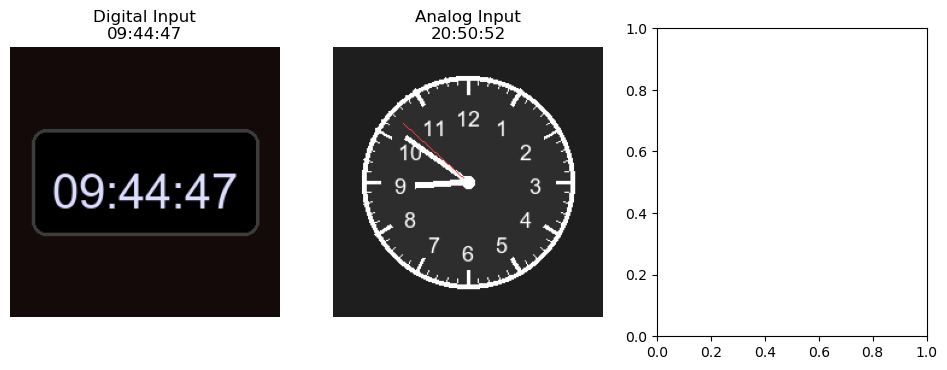

In [10]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(digital_image)
plt.title(f"Digital Input\n{digital_true[0]:02d}:{digital_true[1]:02d}:{digital_true[2]:02d}")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(analog_image)
plt.title(f"Analog Input\n{analog_true[0]:02d}:{analog_true[1]:02d}:{analog_true[2]:02d}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(result["clean_image"])
plt.title("Eraser Output")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(result["final_output"])
plt.title(f"Final Output\n{result['hour']:02d}:{result['minute']:02d}:{result['second']:02d}")
plt.axis("off")

plt.tight_layout()
plt.show()

result["final_output"].save(RESULTS_DIR / "single_pipeline_output.png")

In [11]:
def run_batch_demo(n=6):
    samples = df.sample(n)

    plt.figure(figsize=(4 * n, 12))

    for i, (_, digital_sample) in enumerate(samples.iterrows()):
        analog_sample = df.sample(1).iloc[0]

        digital_image = Image.open(digital_sample["digital_image_path"]).convert("RGB")
        analog_image = Image.open(analog_sample["analog_with_hands_path"]).convert("RGB")

        result = run_pipeline(digital_image, analog_image)

        true_time = (
            int(digital_sample["hour"]),
            int(digital_sample["minute"]),
            int(digital_sample["second"])
        )

        plt.subplot(3, n, i + 1)
        plt.imshow(digital_image)
        plt.title(f"Digital\n{true_time[0]:02d}:{true_time[1]:02d}:{true_time[2]:02d}")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(analog_image)
        plt.title("Analog Input")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(result["final_output"])
        plt.title(f"Output\n{result['hour']:02d}:{result['minute']:02d}:{result['second']:02d}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


run_batch_demo(n=6)

NameError: name 'eraser_model' is not defined

<Figure size 2400x1200 with 0 Axes>